In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import pickle
import json

sys.path.insert(0, "../../utils")

from modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

In [2]:
dataframe = pd.read_csv(f'../../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_PRGN', 'Case_TOTAL',
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_OVR5' : 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,69
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,33
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,12
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,19


In [7]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              #512, 
              #1024, 
              #2048, 
              #4096, 
              8192]

In [8]:
num_of_classes = len(bin_ranges) - 1
print(f"Number of classes: {num_of_classes}")

Number of classes: 8


In [10]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7]

In [11]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [12]:
dataframe['case_bin'] = bins

In [13]:
# dataset = pd.concat([data_0, data_rest])

dataset = dataframe.copy()

In [14]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [15]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256 8192]


In [16]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

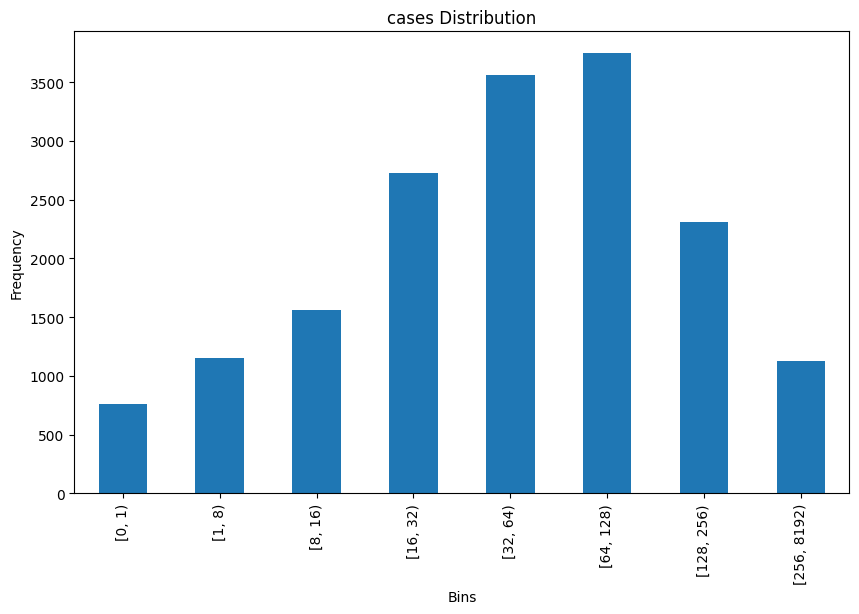

In [17]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [18]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,69,5
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,33,4
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15,2
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,12,2
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16948,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,25,3
16949,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,46,4
16950,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,330,7
16951,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,197,6


In [19]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [20]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [21]:
with open("CM_Nord_rfecv_model_ovr5.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [22]:
with open("CM_Nord_gridcv_best_params_ovr5.json", "r") as f:
    model_params = json.load(f)

In [23]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_pred_list = []
y_test_pred_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    model = xgb.XGBRegressor(**model_params)   
    fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

    y_train_pred = fitted_model.predict(X_train_rfe)
    y_test_pred = fitted_model.predict(X_test_rfe)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_pred_list.append(y_train_pred)
    y_test_pred_list.append(y_test_pred)

    fold_counter += 1

Fold: 1/10
Fold: 2/10
Fold: 3/10
Fold: 4/10
Fold: 5/10
Fold: 6/10
Fold: 7/10
Fold: 8/10
Fold: 9/10
Fold: 10/10


In [60]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_pred = np.concatenate(y_train_pred_list, axis = 0)
y_test_pred = np.concatenate(y_test_pred_list, axis = 0)

y_train_pred = np.clip(np.round(y_train_pred), 0, num_of_classes-1).astype(int)
y_test_pred = np.clip(np.round(y_test_pred), 0, num_of_classes-1).astype(int)

# y_train_pred = np.clip(np.where(y_train_pred <= 2, np.floor(y_train_pred), np.round(y_train_pred)),0,num_of_classes - 1).astype(int)
# y_test_pred = np.clip(np.where(y_test_pred <= 2, np.floor(y_test_pred), np.round(y_test_pred)),0,num_of_classes - 1).astype(int)

In [61]:
results_train = pd.DataFrame({'actual': y_train_true,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test_true,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [62]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.3016
MSE on train set: 0.3301
min prediction: 0
max prediction: 7

MAE on test set: 0.6204
MSE on test set: 0.8748
Error <= 1: 91.24 %
min prediction: 0
max prediction: 7


In [63]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [64]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_prediction',
    group_by='month',
    metric='mae',
    title='Monthly MAE'
)

In [65]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_temp',
    group_by='year',
    metric='mae',
    title='Yearly MAE'
)

In [66]:
plot_hist_plotly(results_test['actual'], results_test['prediction'])